In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings

# 1 Problem Statement and Objective
# Problem Statement:
Customer Segmentation Using Unsupervised Learning
# Objective:
Cluster customers based on spending habits and propose marketing strategies tailored to each
segment.

# 2. Load dataset

In [2]:
df=pd.read_csv(r"C:\Users\EB\PY\Mall_Customers.csv")

# 3. Basic EDA

In [4]:
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [47]:
print(df.info())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Genre                   200 non-null    object 
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
 5   Cluster                 200 non-null    int32  
 6   PCA1                    200 non-null    float64
 7   PCA2                    200 non-null    float64
 8   tsne1                   200 non-null    float32
 9   tsne2                   200 non-null    float32
dtypes: float32(2), float64(2), int32(1), int64(4), object(1)
memory usage: 13.4+ KB
None


In [48]:
print(df.shape) 

(200, 10)


# Visualizations (charts, plots, graphs)

In [7]:
# Visualizing distributions

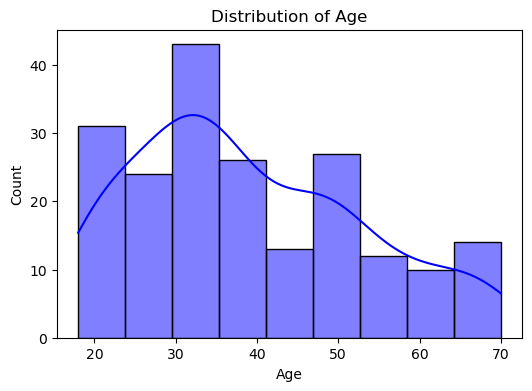

In [24]:
#Age Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Distribution of Age')
plt.show()

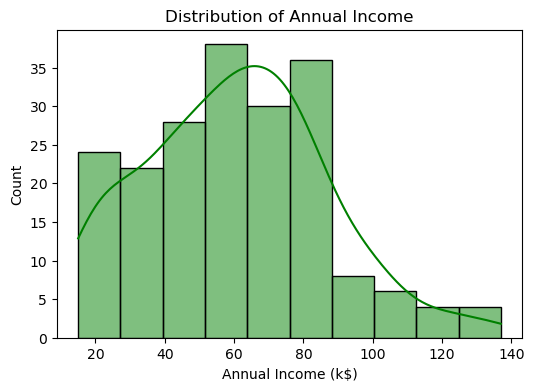

In [25]:
#Annual Income Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['Annual Income (k$)'], kde=True, color='green')
plt.title('Distribution of Annual Income')
plt.show()

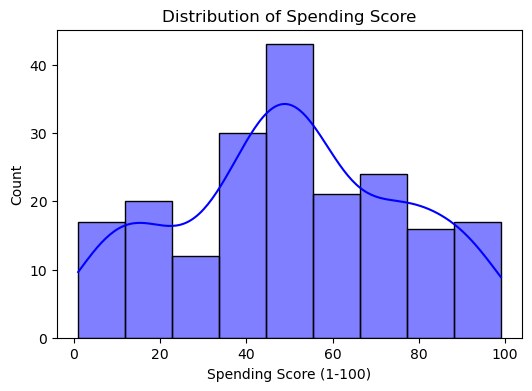

In [41]:
#Spending Score Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['Spending Score (1-100)'], kde=True, color='blue')
plt.title('Distribution of Spending Score')
plt.show()

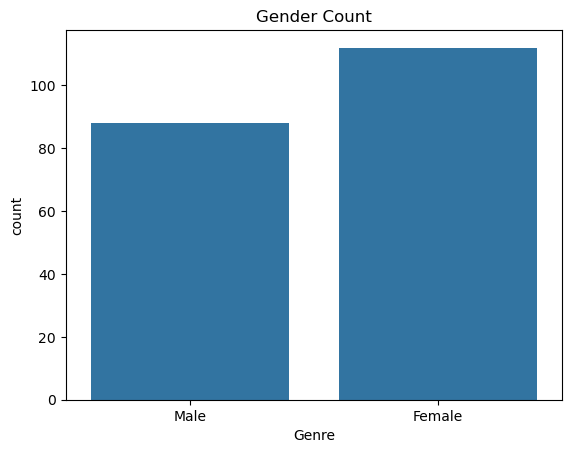

In [46]:
sns.countplot(x='Genre', data=df)
plt.title('Gender Count')
plt.show()

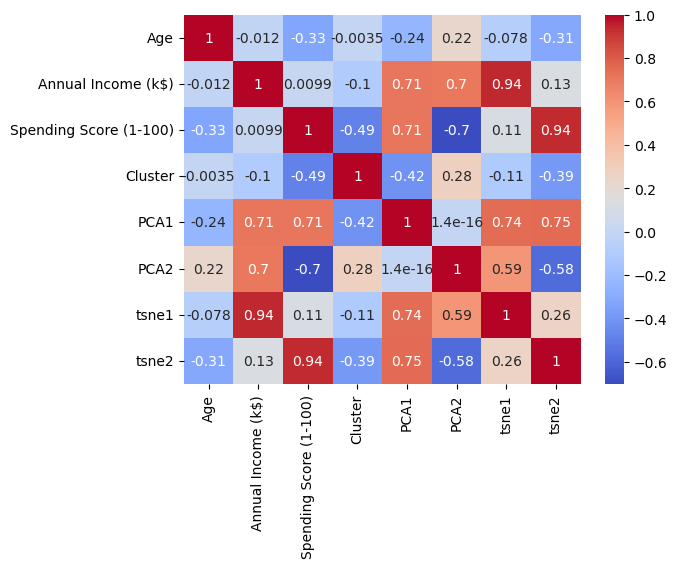

In [49]:
# Correlation Heatmap
sns.heatmap(df.drop('CustomerID', axis=1).corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# 3.Preprocessing
# K-Means Clustering

In [12]:
# Feature Selection & Scaling
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4 Model building and evaluation

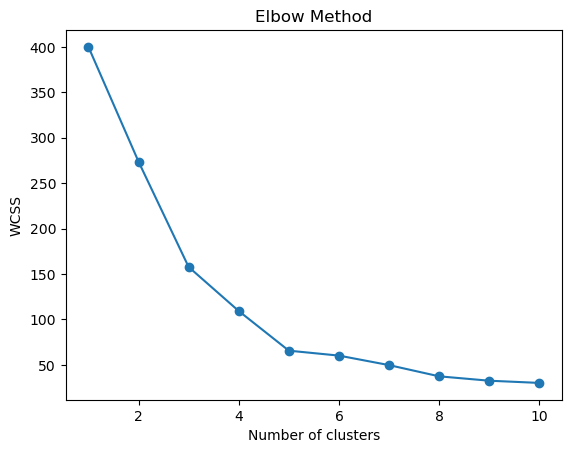

In [16]:
# Elbow Method to find optimal k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
warnings.filterwarnings('ignore')
plt.show()



In [17]:
# Apply K-Means with k=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Dimensionality Reduction (PCA & t-SNE)


In [50]:
# PCA for Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]

In [19]:
# t-SNE for Visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_data = tsne.fit_transform(X_scaled)
df['tsne1'], df['tsne2'] = tsne_data[:, 0], tsne_data[:, 1]


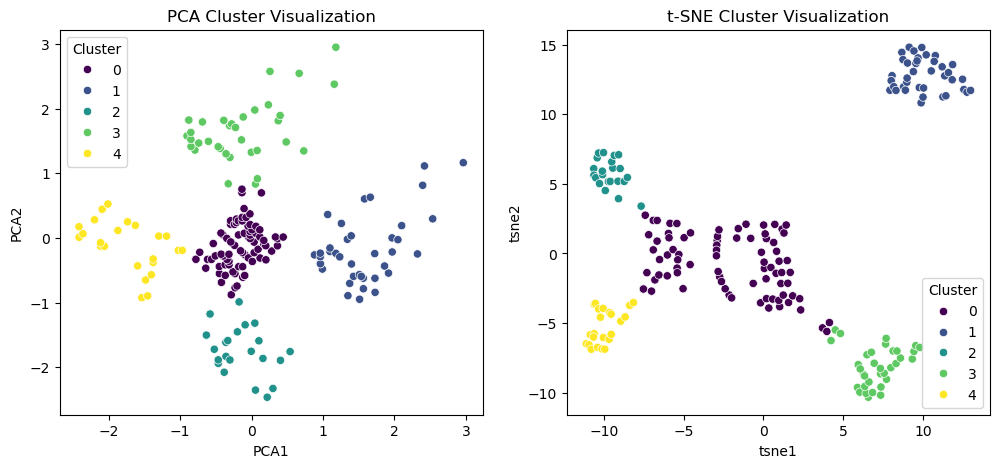

In [20]:
# Plotting PCA results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis')
plt.title('PCA Cluster Visualization')

plt.subplot(1, 2, 2)
sns.scatterplot(x='tsne1', y='tsne2', hue='Cluster', data=df, palette='viridis')
plt.title('t-SNE Cluster Visualization')
plt.show()